In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import json
from networkx.algorithms import bipartite

In [3]:
users = pd.read_csv("users_data.csv")
cards = pd.read_csv("cards_data.csv")
transactions = pd.read_csv("transactions_data.csv")

with open("mcc_code.json", "r") as f:
    mcc_dict = json.load(f)

In [4]:
agg = (
    transactions.groupby(["client_id","merchant_id"])
    .agg(
        tx_count=("id", "count"),
        total_amount=("amount","sum")
    )
    .reset_index()
)

# Get dominant MCC per merchant
merchant_mcc = (
    transactions.groupby("merchant_id")["mcc"]
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

In [5]:
# ===============================
# Build Bipartite Graph
# ===============================
B = nx.Graph()

clients = agg["client_id"].unique()
merchants = agg["merchant_id"].unique()

B.add_nodes_from(clients, bipartite=0, node_type="client")
B.add_nodes_from(merchants, bipartite=1, node_type="merchant")

for _, row in agg.iterrows():
    B.add_edge(
        row["client_id"],
        row["merchant_id"],
        weight=row["tx_count"],
        total_amount=row["total_amount"]
    )

In [7]:
# ===============================
# Merchant Projection
# ===============================
merchant_nodes = [n for n, d in B.nodes(data=True) if d["node_type"] == "merchant"]
G_merchants = bipartite.weighted_projected_graph(B, merchant_nodes)

In [8]:
# ===============================
# Recommendation Function
# ===============================
def recommend_merchants_for_client(client_id, B, G_merchants, top_k=10):

    neighbors = list(B.neighbors(client_id))
    known_merchants = set(
        m for m in neighbors if B.nodes[m].get("node_type") == "merchant"
    )

    scores = {}

    for m in known_merchants:
        if m not in G_merchants:
            continue

        for nbr, edge_data in G_merchants[m].items():
            if nbr in known_merchants:
                continue

            w = edge_data.get("weight", 1.0)
            scores[nbr] = scores.get(nbr, 0) + w

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

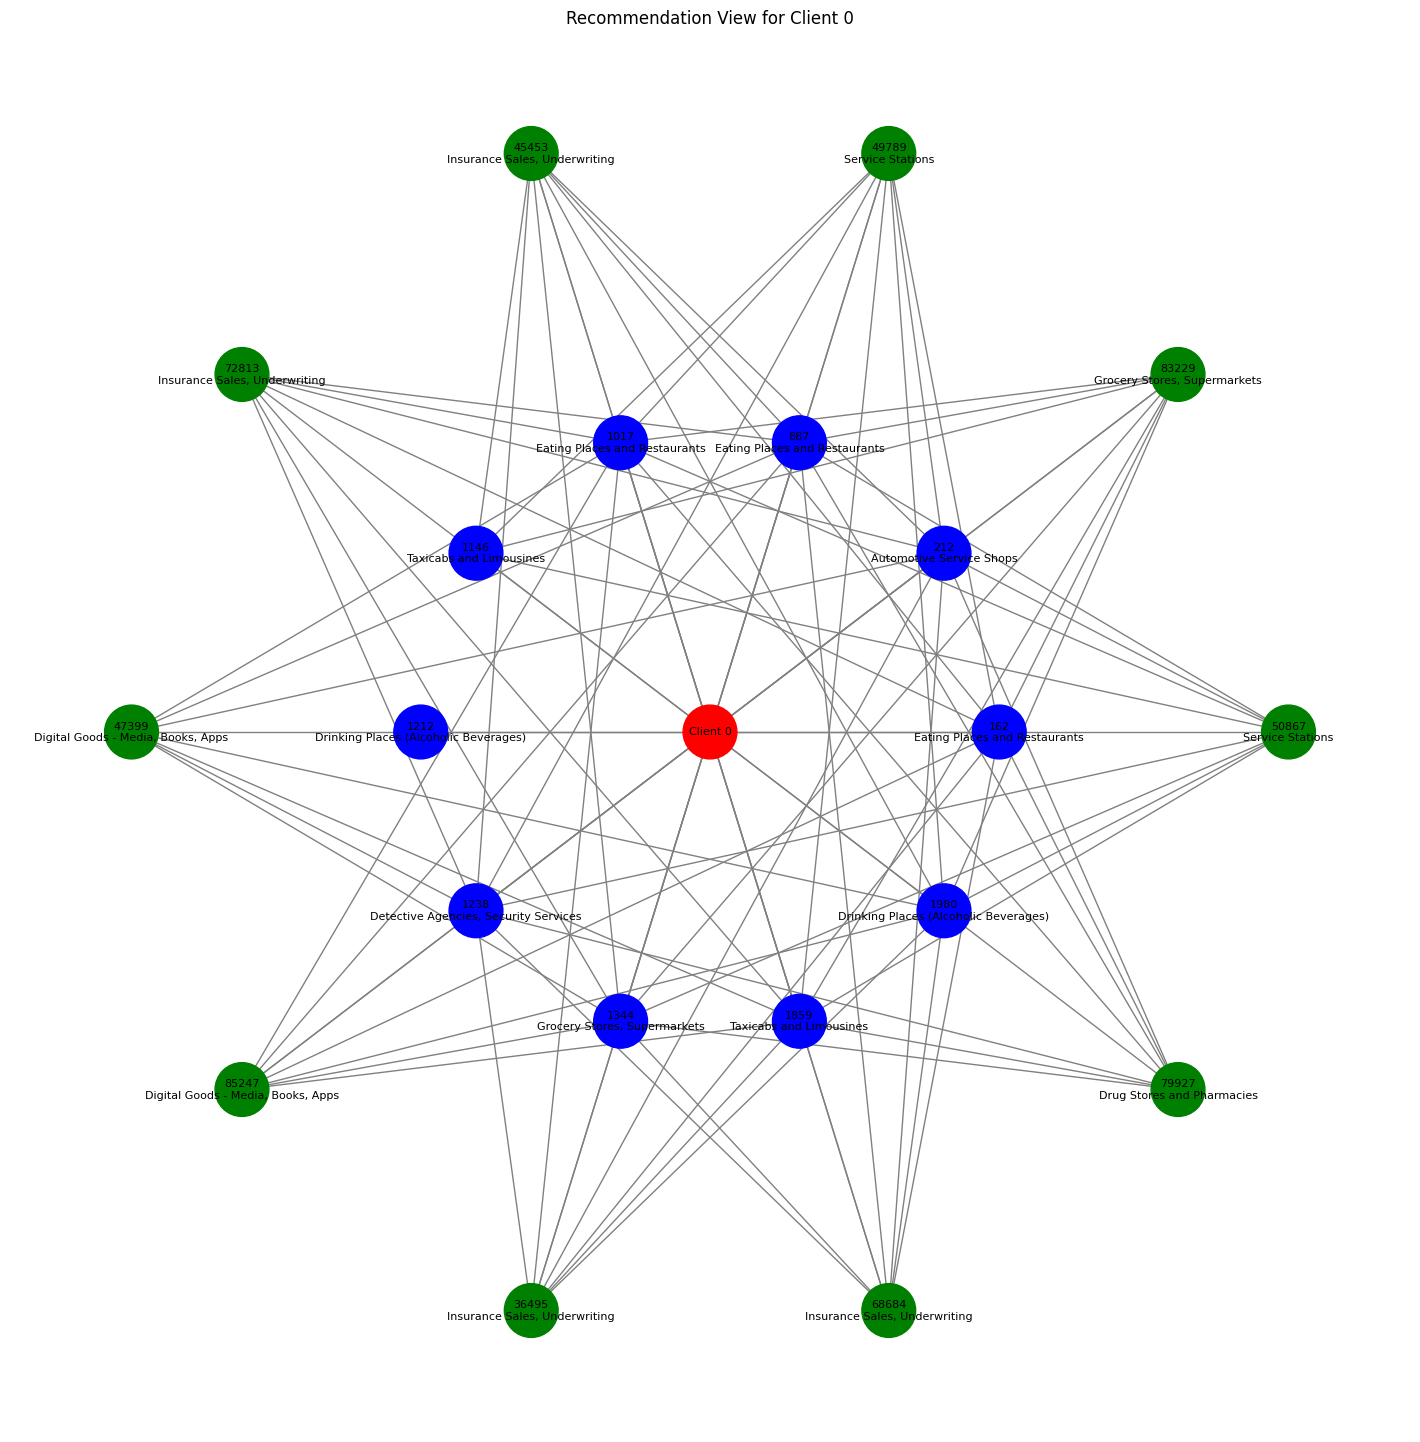

In [9]:
# ===============================
# Structured Recommendation Graph (10 + 10)
# ===============================
example_client = agg["client_id"].iloc[0]

known_merchants = [
    m for m in B.neighbors(example_client)
    if B.nodes[m]["node_type"] == "merchant"
][:10]

recommended_merchants = [
    m for m, _ in recommend_merchants_for_client(
        example_client, B, G_merchants, top_k=10
    )
]

H = nx.Graph()
H.add_node(example_client, node_type="client",
           label=f"Client {example_client}")

# Known merchants
for m in known_merchants:
    mcc_code = str(merchant_mcc.get(m, "Unknown"))
    mcc_desc = mcc_dict.get(mcc_code, "Unknown MCC")

    label = f"{m}\n{mcc_desc}"

    H.add_node(m, node_type="known", label=label)
    H.add_edge(example_client, m)

# Recommended merchants
for m in recommended_merchants:
    mcc_code = str(merchant_mcc.get(m, "Unknown"))
    mcc_desc = mcc_dict.get(mcc_code, "Unknown MCC")

    label = f"{m}\n{mcc_desc}"

    H.add_node(m, node_type="recommended", label=label)

    for km in known_merchants:
        if G_merchants.has_edge(m, km):
            H.add_edge(m, km)

# Layout
pos = {}
pos[example_client] = np.array([0, 0])

radius_inner = 4
radius_outer = 8

# Inner circle
for i, m in enumerate(known_merchants):
    angle = i * 2 * np.pi / len(known_merchants)
    pos[m] = np.array([
        radius_inner * np.cos(angle),
        radius_inner * np.sin(angle)
    ])

# Outer circle
for i, m in enumerate(recommended_merchants):
    angle = i * 2 * np.pi / len(recommended_merchants)
    pos[m] = np.array([
        radius_outer * np.cos(angle),
        radius_outer * np.sin(angle)
    ])

labels = nx.get_node_attributes(H, "label")

node_colors = []
for n in H.nodes():
    if H.nodes[n]["node_type"] == "client":
        node_colors.append("red")
    elif H.nodes[n]["node_type"] == "known":
        node_colors.append("blue")
    else:
        node_colors.append("green")

plt.figure(figsize=(14,14))
nx.draw(H, pos,
        node_color=node_colors,
        node_size=1500,
        edge_color="gray",
        with_labels=False)

nx.draw_networkx_labels(H, pos, labels, font_size=8)
plt.title(f"Recommendation View for Client {example_client}")
plt.axis("off")
plt.show()


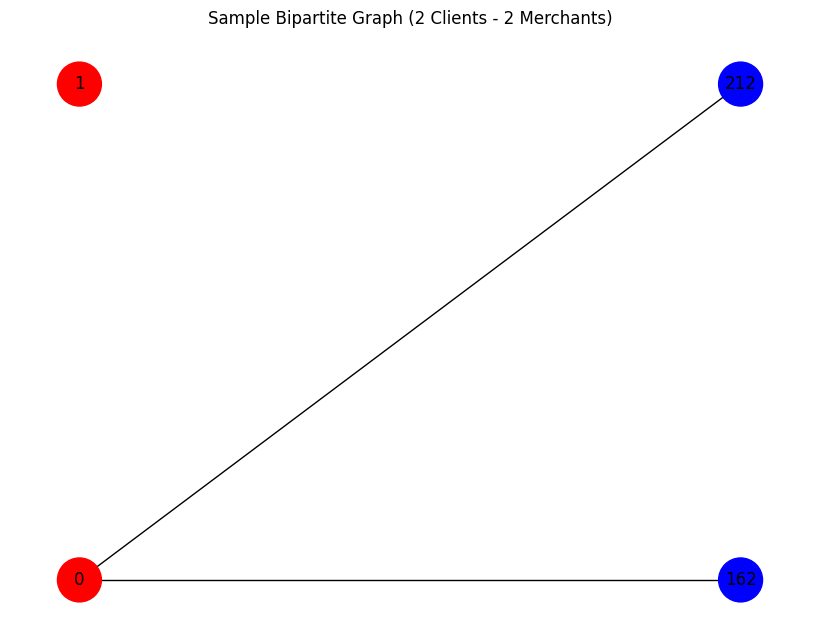

In [10]:
# ===============================
# Small Bipartite Sample View (2 Clients + 2 Merchants)
# ===============================

sample_clients = list(clients[:2])
sample_merchants = list(merchants[:2])

B_sample = B.subgraph(sample_clients + sample_merchants)

pos_sample = nx.bipartite_layout(B_sample, sample_clients)

color_map = []
for node in B_sample:
    if node in sample_clients:
        color_map.append("red")
    else:
        color_map.append("blue")

plt.figure(figsize=(8,6))
nx.draw(B_sample,
        pos_sample,
        node_color=color_map,
        node_size=1000,
        with_labels=True)

plt.title("Sample Bipartite Graph (2 Clients - 2 Merchants)")
plt.show()

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import json
from networkx.algorithms import bipartite

In [ ]:
users = pd.read_csv("users_data.csv")
cards = pd.read_csv("cards_data.csv")
transactions = pd.read_csv("transactions_data.csv")

with open("mcc_code.json", "r") as f:
    mcc_dict = json.load(f)

In [23]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite

# ===============================
# Bucket Client Features
# ===============================

users["yearly_income"] = (
    users["yearly_income"]
    .astype(str)
    .str.replace(",", "", regex=False)  # remove commas
    .str.replace("$", "", regex=False)  # remove $ if exists
)

users["yearly_income"] = pd.to_numeric(
    users["yearly_income"],
    errors="coerce"
)

users["income_bucket"] = pd.qcut(
    users["yearly_income"],
    q=4,
    labels=["Low", "Mid", "High", "Ultra"]
)

users["age_bucket"] = pd.cut(
    users["current_age"],
    bins=[18,25,35,45,55,65,100],
    labels=["18-25","26-35","36-45","46-55","56-65","65+"]
)

In [24]:
agg = (
    transactions.groupby(["client_id","merchant_id"])
    .agg(
        tx_count=("id", "count"),
        total_amount=("amount","sum")
    )
    .reset_index()
)

B = nx.Graph()

clients = agg["client_id"].unique()
merchants = agg["merchant_id"].unique()

B.add_nodes_from(clients, bipartite=0, node_type="client")
B.add_nodes_from(merchants, bipartite=1, node_type="merchant")

for _, row in agg.iterrows():
    B.add_edge(
        row["client_id"],
        row["merchant_id"],
        weight=row["tx_count"]
    )

In [25]:
# Custom Jaccard weight function
def jaccard_weight(G, u, v):
    neighbors_u = set(G[u])
    neighbors_v = set(G[v])
    
    intersection = len(neighbors_u & neighbors_v)
    union = len(neighbors_u | neighbors_v)
    
    if union == 0:
        return 0
    
    return intersection / union

merchant_nodes = [
    n for n, d in B.nodes(data=True)
    if d["node_type"] == "merchant"
]

G_merchants = bipartite.generic_weighted_projected_graph(
    B,
    merchant_nodes,
    weight_function=jaccard_weight
)

In [26]:
# Merge transactions with income bucket
tx_users = transactions.merge(
    users[["id","income_bucket"]],
    left_on="client_id",
    right_on="id"
)

merchant_income_pref = (
    tx_users
    .groupby(["merchant_id","income_bucket"])
    .size()
    .unstack(fill_value=0)
)

# Normalize row-wise (so it becomes proportion)
merchant_income_pref = merchant_income_pref.div(
    merchant_income_pref.sum(axis=1),
    axis=0
)

In [27]:
def recommend_merchants_hybrid(client_id, top_k=10,
                               alpha=0.7, beta=0.3):
    """
    alpha = weight for Jaccard similarity
    beta = weight for income affinity
    """

    if client_id not in B:
        return []

    # Known merchants
    known_merchants = {
        m for m in B.neighbors(client_id)
        if B.nodes[m]["node_type"] == "merchant"
    }

    if not known_merchants:
        return []

    # Get client income bucket
    client_income = users.loc[
        users["id"] == client_id,
        "income_bucket"
    ].values[0]

    scores = {}

    for m in known_merchants:
        if m not in G_merchants:
            continue

        for candidate, edge_data in G_merchants[m].items():

            if candidate in known_merchants:
                continue

            j_score = edge_data.get("weight", 0)

            income_affinity = 0
            if candidate in merchant_income_pref.index:
                income_affinity = merchant_income_pref.loc[
                    candidate, client_income
                ]

            hybrid_score = alpha * j_score + beta * income_affinity

            scores[candidate] = scores.get(candidate, 0) + hybrid_score

    ranked = sorted(scores.items(),
                    key=lambda x: x[1],
                    reverse=True)

    return ranked[:top_k]

In [28]:
example_client = users["id"].iloc[0]

recommendations = recommend_merchants_hybrid(
    example_client,
    top_k=10
)

print(recommendations)

[(np.int64(19363), np.float64(95.78109465303015)), (np.int64(55060), np.float64(89.80027529942015)), (np.int64(34490), np.float64(89.75502665896717)), (np.int64(89069), np.float64(84.87051464942614)), (50867, np.float64(83.55293010281407)), (np.int64(98374), np.float64(80.99989372607621)), (np.int64(22792), np.float64(75.58957652204582)), (79098, np.float64(75.30815035794755)), (np.int64(31893), np.float64(74.76809010024036)), (np.int64(36495), np.float64(72.32396085900024))]


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

def visualize_client_recommendation(client_id, top_k=10):

    known_merchants = [
        m for m in B.neighbors(client_id)
        if B.nodes[m]["node_type"] == "merchant"
    ][:10]

    recommended = recommend_merchants_hybrid(
        client_id,
        top_k=top_k
    )

    recommended_merchants = [m for m, _ in recommended]

    H = nx.Graph()

    H.add_node(
        client_id,
        node_type="client",
        label=f"Client {client_id}"
    )

    # -------------------
    # Known merchants
    # -------------------
    for m in known_merchants:

        mcc_code = str(merchant_mcc.get(m, "Unknown"))
        mcc_desc = mcc_dict.get(mcc_code, "Unknown MCC")

        label = f"{m}\n{mcc_desc}"

        H.add_node(
            m,
            node_type="known",
            label=label
        )

        H.add_edge(client_id, m)

    # -------------------
    # Recommended merchants
    # -------------------
    edge_labels = {}

    for m in recommended_merchants:

        mcc_code = str(merchant_mcc.get(m, "Unknown"))
        mcc_desc = mcc_dict.get(mcc_code, "Unknown MCC")

        label = f"{m}\n{mcc_desc}"

        H.add_node(
            m,
            node_type="recommended",
            label=label
        )

        for km in known_merchants:
            if G_merchants.has_edge(m, km):

                # Get Jaccard similarity
                j_weight = G_merchants[m][km].get("weight", 0)

                H.add_edge(m, km)

                # Store formatted edge label
                edge_labels[(m, km)] = f"{j_weight:.2f}"

    # ===============================
    # Layout
    # ===============================
    pos = {}
    pos[client_id] = np.array([0, 0])

    radius_inner = 4
    radius_outer = 8

    for i, m in enumerate(known_merchants):
        angle = i * 2 * np.pi / len(known_merchants)
        pos[m] = np.array([
            radius_inner * np.cos(angle),
            radius_inner * np.sin(angle)
        ])

    for i, m in enumerate(recommended_merchants):
        angle = i * 2 * np.pi / len(recommended_merchants)
        pos[m] = np.array([
            radius_outer * np.cos(angle),
            radius_outer * np.sin(angle)
        ])

    labels = nx.get_node_attributes(H, "label")

    node_colors = []
    for n in H.nodes():
        if H.nodes[n]["node_type"] == "client":
            node_colors.append("red")
        elif H.nodes[n]["node_type"] == "known":
            node_colors.append("blue")
        else:
            node_colors.append("green")

    plt.figure(figsize=(14,14))

    nx.draw(
        H, pos,
        node_color=node_colors,
        node_size=1500,
        edge_color="gray",
        with_labels=False
    )

    nx.draw_networkx_labels(
        H, pos,
        labels,
        font_size=8
    )

    # 🔥 Draw Jaccard similarity on edges
    nx.draw_networkx_edge_labels(
        H, pos,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(f"Hybrid Recommendation View for Client {client_id}")
    plt.axis("off")
    plt.show()

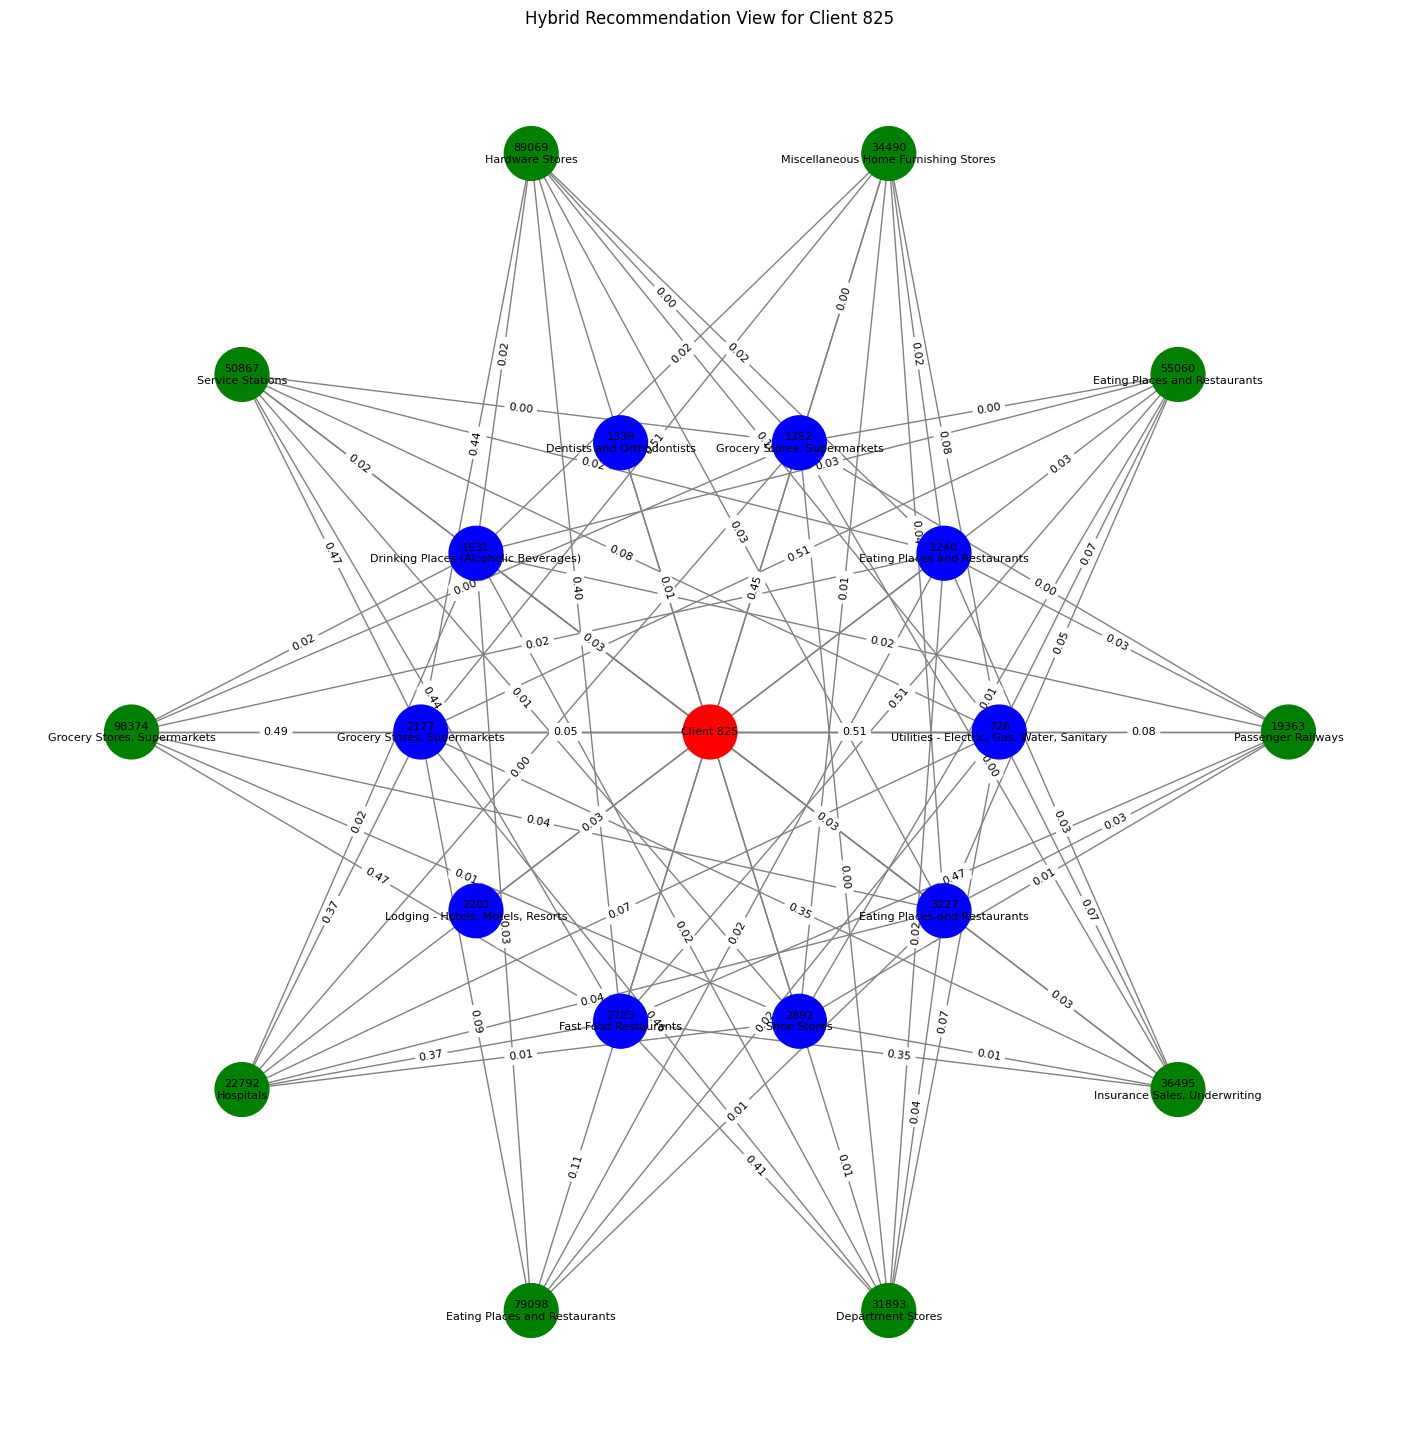

In [34]:
example_client = users["id"].iloc[0]
visualize_client_recommendation(example_client, top_k=10)

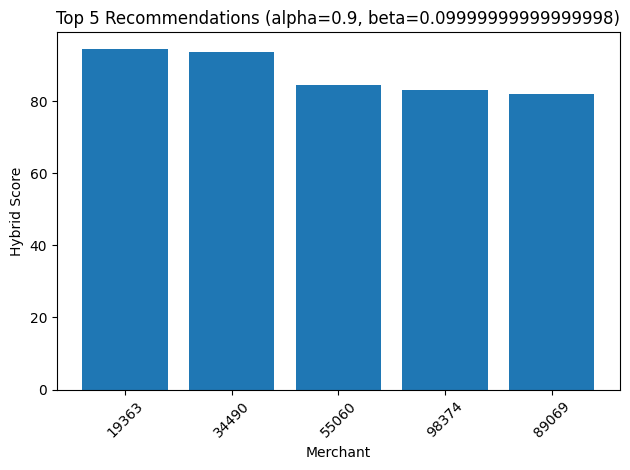

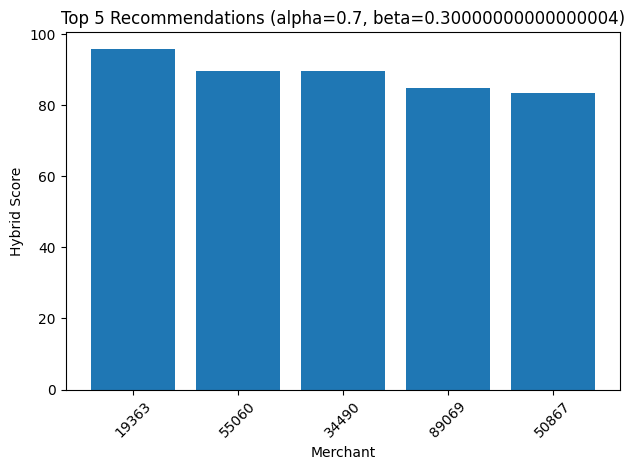

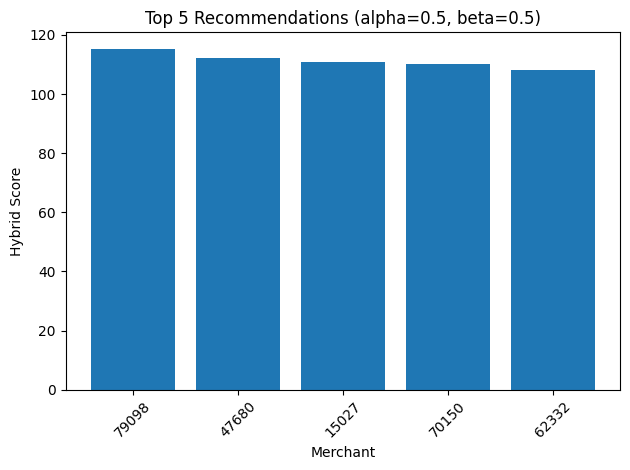

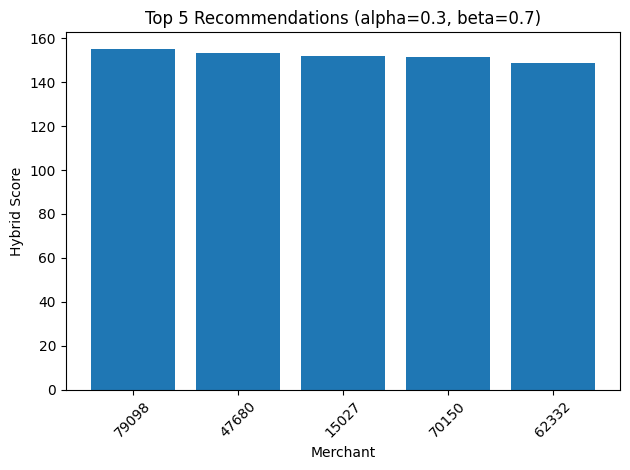

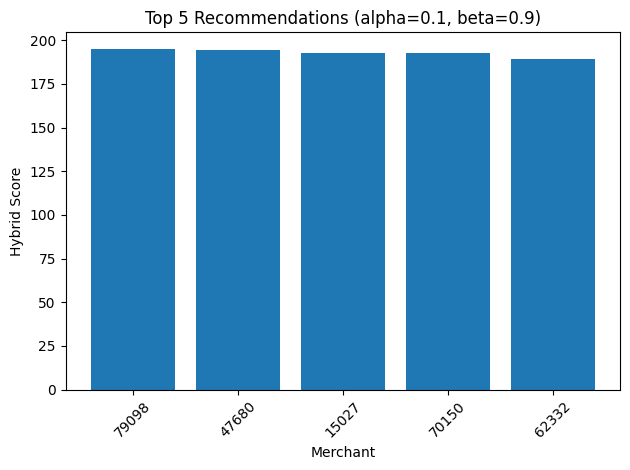

In [35]:
import matplotlib.pyplot as plt

def get_scores_for_alpha(client_id, alpha, top_k=5):

    beta = 1 - alpha

    known_merchants = {
        m for m in B.neighbors(client_id)
        if B.nodes[m]["node_type"] == "merchant"
    }

    client_income = users.loc[
        users["id"] == client_id,
        "income_bucket"
    ].values[0]

    scores = {}

    for m in known_merchants:
        if m not in G_merchants:
            continue

        for candidate, edge_data in G_merchants[m].items():

            if candidate in known_merchants:
                continue

            j_score = edge_data.get("weight", 0)

            income_affinity = 0
            if candidate in merchant_income_pref.index:
                income_affinity = merchant_income_pref.loc[
                    candidate, client_income
                ]

            hybrid_score = alpha * j_score + beta * income_affinity
            scores[candidate] = scores.get(candidate, 0) + hybrid_score

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


# -----------------------------
# Compare multiple alpha values
# -----------------------------

example_client = users["id"].iloc[0]

alpha_values = [0.9, 0.7, 0.5, 0.3, 0.1]

for alpha in alpha_values:

    ranked = get_scores_for_alpha(example_client, alpha, top_k=5)

    merchants = [str(m) for m, _ in ranked]
    scores = [score for _, score in ranked]

    plt.figure()
    plt.bar(merchants, scores)
    plt.title(f"Top 5 Recommendations (alpha={alpha}, beta={1-alpha})")
    plt.xticks(rotation=45)
    plt.ylabel("Hybrid Score")
    plt.xlabel("Merchant")
    plt.tight_layout()
    plt.show()

In [36]:
import pandas as pd

# Choose specific clients OR randomly sample
sample_clients = transactions["client_id"].drop_duplicates().sample(3).tolist()

# Filter only those clients
sub_df = transactions[transactions["client_id"].isin(sample_clients)]

print("Selected Clients:", sample_clients)
print(sub_df.head())

Selected Clients: [473, 877, 1696]
           id                 date  client_id  card_id  amount  \
187   7475539  2010-01-01 05:38:00       1696     2408   $4.02   
226   7475586  2010-01-01 06:03:00       1696     2408   $9.68   
369   7475755  2010-01-01 06:53:00       1696     2408   $3.41   
959   7476469  2010-01-01 09:44:00        877     3877  $81.80   
1579  7477220  2010-01-01 12:18:00       1696     2408   $9.94   

                use_chip  merchant_id   merchant_city merchant_state      zip  \
187    Swipe Transaction        35451  Merritt Island             FL  32952.0   
226   Online Transaction        39021          ONLINE            NaN      NaN   
369    Swipe Transaction        75781  Merritt Island             FL  32953.0   
959    Swipe Transaction        96642            Mesa             AZ  85201.0   
1579  Online Transaction        50404          ONLINE            NaN      NaN   

       mcc errors  
187   5812    NaN  
226   4784    NaN  
369   5411    NaN  
9

In [40]:
sample_clients = [473, 877, 1696]
sub_df = transactions[transactions["client_id"].isin(sample_clients)]
sub_df.count()

id                45896
date              45896
client_id         45896
card_id           45896
amount            45896
use_chip          45896
merchant_id       45896
merchant_city     45896
merchant_state    35885
zip               35526
mcc               45896
errors             1241
dtype: int64

In [41]:
sub_df = transactions[
    transactions["client_id"].isin(sample_clients)
]

# Aggregate to client-merchant level
agg_df = (
    sub_df
    .groupby(["client_id", "merchant_id"])
    .size()
    .reset_index(name="transaction_count")
)

print("Original rows:", len(sub_df))
print("After aggregation:", len(agg_df))
agg_df.head()

Original rows: 45896
After aggregation: 718


,client_id,merchant_id,transaction_count
0,473,235,9
1,473,1102,7
2,473,3558,6
3,473,4439,27
4,473,5594,1


In [42]:
agg_df = (
    agg_df
    .sort_values(["client_id", "transaction_count"], ascending=False)
    .groupby("client_id")
    .head(5)
)

print("After limiting top 5 merchants per client:", len(agg_df))

After limiting top 5 merchants per client: 15


In [43]:
import networkx as nx

B_small = nx.Graph()

# Add clients
for client in agg_df["client_id"].unique():
    B_small.add_node(f"C_{client}", type="client")

# Add merchants + edges
for _, row in agg_df.iterrows():
    B_small.add_node(f"M_{row['merchant_id']}", type="merchant")
    B_small.add_edge(
        f"C_{row['client_id']}",
        f"M_{row['merchant_id']}",
        weight=row["transaction_count"]
    )

print("Nodes:", B_small.number_of_nodes())
print("Edges:", B_small.number_of_edges())

Nodes: 15
Edges: 15


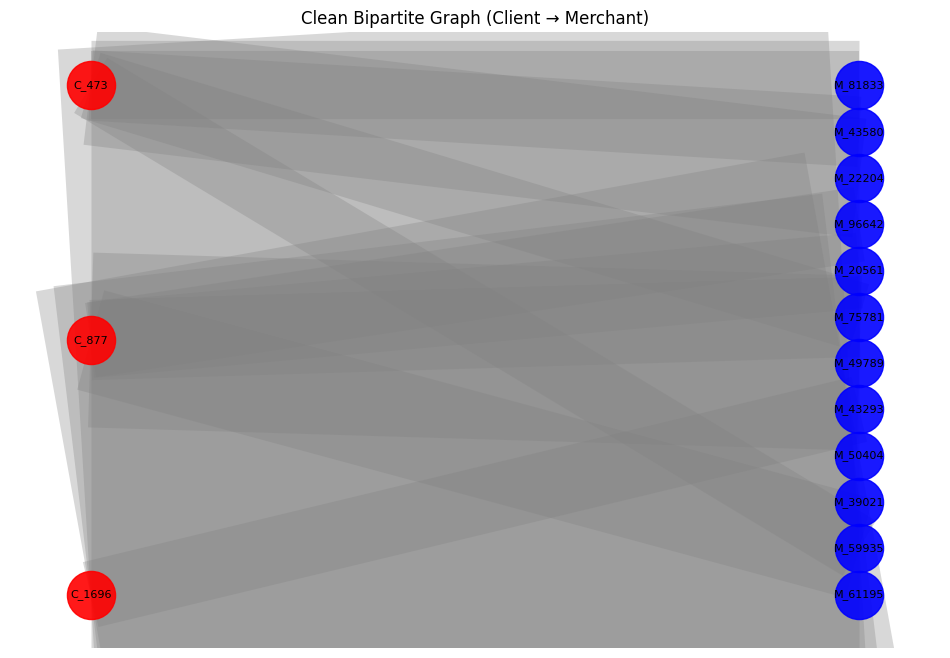

In [46]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

clients = [n for n, d in B_small.nodes(data=True) if d["type"] == "client"]
merchants = [n for n, d in B_small.nodes(data=True) if d["type"] == "merchant"]

pos = {}

# Spread clients vertically
client_y = np.linspace(0, 10, len(clients))
for i, node in enumerate(clients):
    pos[node] = (0, client_y[i])

# Spread merchants vertically
merchant_y = np.linspace(0, 10, len(merchants))
for i, node in enumerate(merchants):
    pos[node] = (5, merchant_y[i])

plt.figure(figsize=(12, 8))

# Draw nodes
nx.draw_networkx_nodes(
    B_small, pos,
    nodelist=clients,
    node_color="red",
    node_size=1200,
    alpha=0.9
)

nx.draw_networkx_nodes(
    B_small, pos,
    nodelist=merchants,
    node_color="blue",
    node_size=1200,
    alpha=0.9
)

# Draw edges with transparency
edges = B_small.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]

nx.draw_networkx_edges(
    B_small, pos,
    width=[w * 0.1 for w in weights],   # reduce scaling
    alpha=0.3,
    edge_color="gray"
)

# Labels
nx.draw_networkx_labels(B_small, pos, font_size=8)

plt.title("Clean Bipartite Graph (Client → Merchant)")
plt.axis("off")
plt.show()

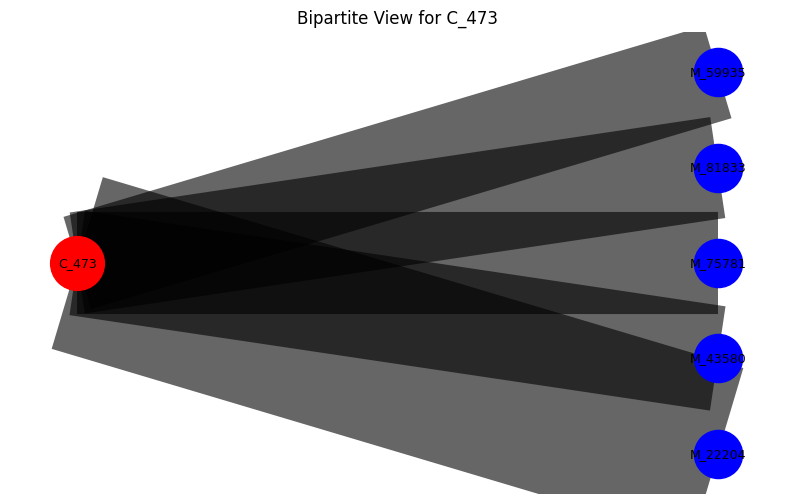

In [47]:
client_to_view = "C_473"  # change as needed

# Get connected merchants
connected_merchants = list(B_small.neighbors(client_to_view))

# Build subgraph
nodes_to_draw = [client_to_view] + connected_merchants
G_one = B_small.subgraph(nodes_to_draw)

pos = {}
pos[client_to_view] = (0, 5)

merchant_y = np.linspace(0, 10, len(connected_merchants))
for i, m in enumerate(connected_merchants):
    pos[m] = (5, merchant_y[i])

plt.figure(figsize=(10, 6))

nx.draw_networkx_nodes(G_one, pos,
                       nodelist=[client_to_view],
                       node_color="red",
                       node_size=1500)

nx.draw_networkx_nodes(G_one, pos,
                       nodelist=connected_merchants,
                       node_color="blue",
                       node_size=1200)

weights = [G_one[u][v]["weight"] for u, v in G_one.edges()]
nx.draw_networkx_edges(G_one, pos,
                       width=[w * 0.15 for w in weights],
                       alpha=0.6)

nx.draw_networkx_labels(G_one, pos, font_size=9)

plt.title(f"Bipartite View for {client_to_view}")
plt.axis("off")
plt.show()